<div style="background: linear-gradient(135deg,#0f3460,#16213e); padding:2.5rem 2rem; border-radius:12px; text-align:center; color:white; margin-bottom:1rem;">
  <h1 style="font-size:2rem; margin:0; font-weight:800;">📊 Sales Data Analytics Dashboard</h1>
  <p style="margin:0.6rem 0 0; font-size:1rem; opacity:0.85;">IBM SkillsBuild — Data Analytics with AI Academic Internship</p>
  <p style="margin:0.3rem 0 0; font-size:0.88rem; opacity:0.65;">Submitted by: <strong>Chitesh</strong></p>
</div>

---
## 1. Project Overview

This project demonstrates a complete **end-to-end data analytics pipeline** on a real-world sales dataset. The workflow covers:

- Loading a raw Excel dataset with intentional data quality issues
- Performing systematic data cleaning and standardisation
- Conducting exploratory data analysis (EDA)
- Analysing sales performance by category, region, and time
- Deriving actionable business insights from the cleaned data

The final output is a cleaned CSV (`cleaned_data.csv`) and an interactive HTML dashboard (`dashboard.html`) generated entirely in Python — no server required.

| Item | Detail |
|------|--------|
| **Dataset** | `excelsheet.xlsx` — Raw_Data sheet |
| **Raw Rows** | 2,000 |
| **Cleaned Rows** | 1,891 |
| **Columns** | Order_ID, Order_Date, Customer_ID, Product, Category, Region, Quantity, Revenue, Profit |
| **Output** | `cleaned_data.csv`, `dashboard.html` |

---
## 2. Problem Statement

A retail business maintains its sales records in an Excel file. The raw data suffers from several quality issues that make it unreliable for analysis:

- **Duplicate records** — the same order appears more than once
- **Invalid dates** — impossible calendar dates such as 31-Feb-2026 and 00-Jun-2026
- **Inconsistent casing** — category values like `electronics`, `ELECTRONICS`, and `Electronics` represent the same group
- **Mixed currency formats** — revenue stored as `₹50000`, `374814 INR`, `1,51,844` instead of a plain number
- **Negative / missing quantities** — orders with no quantity or negative stock entries
- **Missing identifiers** — blank Customer_ID and Product fields

**Goal:** Clean the dataset, standardise all columns, and produce a reliable analytical foundation to answer key business questions about revenue, profit, top products, and regional performance.

---
## 3. Objectives

1. Load and inspect the raw Excel dataset
2. Identify and quantify all data quality issues
3. Apply systematic cleaning to produce a zero-null, consistent dataset
4. Perform exploratory data analysis across categories, regions, and time
5. Visualise key metrics with bar charts, pie charts, and trend lines
6. Derive actionable business insights and present findings

---
## 4. Technologies Used

| Library | Version | Purpose |
|---------|---------|--------|
| **Python** | 3.10+ | Core programming language |
| **pandas** | 2.x | Data loading, cleaning, aggregation |
| **numpy** | 1.24+ | Numeric operations |
| **openpyxl** | 3.1+ | Reading `.xlsx` Excel files |
| **matplotlib** | 3.x | Static visualisations |
| **seaborn** | 0.13+ | Enhanced statistical plots |
| **re** | stdlib | Regular expressions for revenue cleaning |
| **Chart.js** | 4.4 (CDN) | Interactive browser dashboard |

---
## 5. Import Libraries

In [77]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime

warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})
sns.set_theme(style='dark', rc=plt.rcParams)

PALETTE = ['#58a6ff','#3fb950','#bc8cff','#f78166','#e3b341','#79c0ff','#56d364','#ffa657']
print('Libraries imported successfully.')

Libraries imported successfully.


---
## 6. Load the Raw Dataset

In [78]:
raw = pd.read_excel('excelsheet.xlsx', sheet_name='Raw_Data')
print(f'Raw dataset loaded.')
print(f'Shape : {raw.shape}')
print(f'Columns: {list(raw.columns)}')

Raw dataset loaded.
Shape : (2000, 9)
Columns: ['Order_ID', 'Order_Date', 'Customer_ID', 'Product', 'Category', 'Region', 'Quantity', 'Revenue', 'Profit']


In [79]:
raw.head(10)

,Order_ID,Order_Date,Customer_ID,Product,Category,Region,Quantity,Revenue,Profit
0,1001,2026-01-06 00:00:00,C001,Laptop,Electronics,Delhi,1.0,65000,8000.0
1,1002,2026-03-06 00:00:00,C002,Phone,Electronics,delhi,2.0,â‚¹50000,6000.0
2,1003,31-02-2026,C003,Headphones,electronics,Mumbai,1.0,5000,1200.0
3,1004,2026-05-06 00:00:00,C004,Chair,Furniture,Bangalore,-3.0,12000,2500.0
4,1005,2026-03-07 00:00:00,C314,Vacuum Cleaner,Home,Delhi,NaN,8506,1455.0
5,1006,18-05-2026,C359,Chair,FURNITURE,chennai,1.0,4307,892.0
6,1007,2026-02-08 00:00:00,C241,Headphones,Electronics,Kolkata,6.0,39396,7334.0
7,1008,15-01-2026,C314,Camera,Electronics,Hyderabad,6.0,374814 INR,51761.0
8,1009,30-05-2026,C290,Bookshelf,Furniture,Chennai,2.0,22960,5742.0
9,1010,22-05-2026,C447,Desk,Furniture,Mumbai,2.0,26696,6419.0


---
## 7. Inspect the Raw Dataset

In [80]:
print('=== Data Types ===')
print(raw.dtypes)
print(f'\n=== Shape ===')
print(f'Rows: {raw.shape[0]}  |  Columns: {raw.shape[1]}')

=== Data Types ===
Order_ID         int64
Order_Date      object
Customer_ID     object
Product         object
Category        object
Region          object
Quantity       float64
Revenue         object
Profit         float64
dtype: object

=== Shape ===
Rows: 2000  |  Columns: 9


In [81]:
print('=== Missing Values ===')
missing = raw.isnull().sum()
missing_pct = (missing / len(raw) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

=== Missing Values ===


,Missing Count,Missing %
Order_ID,0,0.00
Order_Date,0,0.00
Customer_ID,26,1.30
Product,7,0.35
Category,0,0.00
Region,16,0.80
Quantity,23,1.15
Revenue,27,1.35
Profit,29,1.45


In [82]:
print(f'Exact duplicate rows : {raw.duplicated().sum()}')
print(f'\nSample duplicate rows:')
raw[raw.duplicated(keep=False)].sort_values('Order_ID').head(6)

Exact duplicate rows : 23

Sample duplicate rows:


,Order_ID,Order_Date,Customer_ID,Product,Category,Region,Quantity,Revenue,Profit
196,1197,22-03-2026,C044,Shoes,Apparel,BANGALORE,2.0,â‚¹4250,1080.0
197,1197,22-03-2026,C044,Shoes,Apparel,BANGALORE,2.0,â‚¹4250,1080.0
248,1248,19-06-2026,C382,Makeup Kit,Beauty,Hyderabad,2.0,6086,1968.0
249,1248,19-06-2026,C382,Makeup Kit,Beauty,Hyderabad,2.0,6086,1968.0
392,1391,2026-10-03 00:00:00,C076,Tablet,Electronics,Bangalore,NaN,37325,4005.0
393,1391,2026-10-03 00:00:00,C076,Tablet,Electronics,Bangalore,NaN,37325,4005.0


In [83]:
print('=== Unique Category values (raw) ===')
print(sorted(raw['Category'].dropna().unique()))

print('\n=== Unique Region values (raw) ===')
print(sorted(raw['Region'].dropna().unique()))

=== Unique Category values (raw) ===
['APPAREL', 'Apparel', 'BEAUTY', 'Beauty', 'ELECTRONICS', 'Electronics', 'FURNITURE', 'Furniture', 'HOME', 'Home', 'apparel', 'beauty', 'electronics', 'furniture', 'home']

=== Unique Region values (raw) ===
['BANGALORE', 'Bangalore', 'CHENNAI', 'Chennai', 'DELHI', 'Delhi', 'HYDERABAD', 'Hyderabad', 'KOLKATA', 'Kolkata', 'MUMBAI', 'Mumbai', 'PUNE', 'Pune', 'bangalore', 'chennai', 'delhi', 'hyderabad', 'kolkata', 'mumbai', 'pune']


In [84]:
# Show examples of dirty Revenue values
dirty_rev = raw[raw['Revenue'].astype(str).str.contains(r'[₹â‚¹a-zA-Z,]', na=False)]
print(f'Rows with non-numeric Revenue: {len(dirty_rev)}')
dirty_rev[['Order_ID','Revenue']].head(10)

Rows with non-numeric Revenue: 350


,Order_ID,Revenue
1,1002,â‚¹50000
7,1008,374814 INR
13,1014,â‚¹3440
25,1026,â‚¹46652
31,1032,18300 INR
32,1033,29676 INR
43,1044,13740 INR
62,1063,41760 INR
71,1072,â‚¹9984
72,1073,â‚¹20793


In [85]:
raw_qty = pd.to_numeric(raw['Quantity'], errors='coerce')
print(f'Missing Quantity  : {raw_qty.isna().sum()}')
print(f'Negative Quantity : {(raw_qty < 0).sum()}')
print(f'Zero Quantity     : {(raw_qty == 0).sum()}')

Missing Quantity  : 23
Negative Quantity : 41
Zero Quantity     : 0


---
## 8. Data Cleaning

The following 13 steps replicate exactly what `data_cleaner.py` performs.

| Step | Operation |
|------|-----------|
| 1 | Drop unnamed / empty columns |
| 2 | Remove exact duplicate rows |
| 3 | Fix Order_ID (float → int) |
| 4 | Parse & validate Order_Date (multiple formats) |
| 5 | Fill missing Customer_ID with UNKNOWN |
| 6 | Fill missing Product with UNKNOWN |
| 7 | Standardise Category to Title Case |
| 8 | Standardise Region to Title Case |
| 9 | Fix Quantity — remove ≤ 0 or missing |
| 10 | Clean Revenue — strip ₹ / INR / commas |
| 11 | Fix Profit — fill missing with 0 |
| 12 | Add Sales column |
| 13 | Final ordering and export |

In [86]:
# ── Step 1: Drop unnamed / empty columns ─────────────────────────────────
df = raw.copy()
before_cols = df.shape[1]
unnamed_cols = [c for c in df.columns if str(c).startswith('Unnamed')]
df.drop(columns=unnamed_cols, inplace=True)
df.columns = [c.strip() for c in df.columns]
print(f'Columns before: {before_cols}  →  after: {df.shape[1]}')
print(f'Dropped: {unnamed_cols}')

Columns before: 9  →  after: 9
Dropped: []


In [87]:
# ── Step 2: Remove exact duplicate rows ──────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
dupes_removed = before - len(df)
print(f'Duplicate rows removed : {dupes_removed}')
print(f'Rows remaining         : {len(df)}')

Duplicate rows removed : 23
Rows remaining         : 1977


In [88]:
# ── Step 3: Fix Order_ID (float 1001.0 → int 1001) ───────────────────────
df['Order_ID'] = pd.to_numeric(df['Order_ID'], errors='coerce')
df.dropna(subset=['Order_ID'], inplace=True)
df['Order_ID'] = df['Order_ID'].astype(int)
print('Order_ID sample:', df['Order_ID'].head(5).tolist())

Order_ID sample: [1001, 1002, 1003, 1004, 1005]


In [89]:
# ── Step 4: Parse & validate Order_Date ──────────────────────────────────
def parse_date(val):
    """Try multiple common formats; return NaT for anything unparseable."""
    if pd.isna(val):
        return pd.NaT
    s = str(val).strip()
    if isinstance(val, datetime):
        return val
    for fmt in ('%Y-%m-%d', '%d-%m-%Y', '%m-%d-%Y', '%d/%m/%Y'):
        try:
            return datetime.strptime(s, fmt)
        except ValueError:
            pass
    try:
        return pd.to_datetime(s, dayfirst=True)
    except Exception:
        return pd.NaT

df['Order_Date'] = df['Order_Date'].apply(parse_date)
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

before = len(df)
df.dropna(subset=['Order_Date'], inplace=True)
invalid_dates = before - len(df)
print(f'Invalid / impossible dates removed : {invalid_dates}')
print(f'Date range: {df["Order_Date"].min().date()}  →  {df["Order_Date"].max().date()}')

Invalid / impossible dates removed : 24
Date range: 2026-01-01  →  2026-12-08


In [90]:
# ── Step 5: Fix Customer_ID ───────────────────────────────────────────────
df['Customer_ID'] = df['Customer_ID'].fillna('UNKNOWN').astype(str).str.strip()
df['Customer_ID'] = df['Customer_ID'].replace('nan', 'UNKNOWN')

# ── Step 6: Fix Product ───────────────────────────────────────────────────
df['Product'] = df['Product'].fillna('UNKNOWN').astype(str).str.strip()
df['Product'] = df['Product'].replace('', 'UNKNOWN')

print(f'Rows with UNKNOWN Customer_ID : {(df["Customer_ID"]=="UNKNOWN").sum()}')
print(f'Rows with UNKNOWN Product     : {(df["Product"]=="UNKNOWN").sum()}')

Rows with UNKNOWN Customer_ID : 26
Rows with UNKNOWN Product     : 6


In [91]:
# ── Step 7: Standardise Category (title-case) ─────────────────────────────
df['Category'] = df['Category'].fillna('Unknown').astype(str).str.strip().str.title()

# ── Step 8: Standardise Region (title-case) ───────────────────────────────
df['Region'] = df['Region'].fillna('Unknown').astype(str).str.strip().str.title()
df['Region'] = df['Region'].replace('', 'Unknown')

print('Unique Categories after cleaning:', sorted(df['Category'].unique()))
print('Unique Regions    after cleaning:', sorted(df['Region'].unique()))

Unique Categories after cleaning: ['Apparel', 'Beauty', 'Electronics', 'Furniture', 'Home']
Unique Regions    after cleaning: ['Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Kolkata', 'Mumbai', 'Pune', 'Unknown']


In [92]:
# ── Step 9: Fix Quantity ──────────────────────────────────────────────────
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
before = len(df)
df = df[df['Quantity'].notna() & (df['Quantity'] > 0)]
bad_qty = before - len(df)
df['Quantity'] = df['Quantity'].astype(int)
print(f'Rows removed (Quantity ≤ 0 or missing) : {bad_qty}')
print(f'Quantity range: {df["Quantity"].min()} – {df["Quantity"].max()}')

Rows removed (Quantity ≤ 0 or missing) : 62
Quantity range: 1 – 6


In [93]:
# ── Step 10: Clean Revenue ────────────────────────────────────────────────
def clean_revenue(val):
    """Strip ₹ symbol, INR text, commas, spaces; return float."""
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    s = re.sub(r'[₹â‚¹\s]', '', s)
    s = re.sub(r'INR', '', s, flags=re.IGNORECASE)
    s = s.replace(',', '')
    try:
        return float(s)
    except ValueError:
        return np.nan

df['Revenue'] = df['Revenue'].apply(clean_revenue)
revenue_median = df['Revenue'].median()
nan_rev = df['Revenue'].isna().sum()
df['Revenue'] = df['Revenue'].fillna(revenue_median).round(2)

print(f'Revenue NaN filled with median (₹{revenue_median:,.0f}) : {nan_rev} rows')
print(f'Revenue range: ₹{df["Revenue"].min():,.0f} – ₹{df["Revenue"].max():,.0f}')

Revenue NaN filled with median (₹18,681) : 27 rows
Revenue range: ₹356 – ₹2,677,920


In [94]:
# ── Step 11: Fix Profit ───────────────────────────────────────────────────
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')
nan_pro = df['Profit'].isna().sum()
df['Profit'] = df['Profit'].fillna(0).round(2)
print(f'Profit NaN filled with 0 : {nan_pro} rows')

# ── Step 12: Add Sales column ─────────────────────────────────────────────
df['Sales'] = df['Revenue']   # Revenue = total order value
print('Sales column added.')

Profit NaN filled with 0 : 28 rows
Sales column added.


In [95]:
# ── Step 13: Final ordering and export ───────────────────────────────────
column_order = ['Order_ID','Order_Date','Customer_ID','Product',
                'Category','Region','Quantity','Revenue','Profit','Sales']
df = df[column_order]
df.sort_values('Order_ID', inplace=True)
df.reset_index(drop=True, inplace=True)
df.to_csv('cleaned_data.csv', index=False)
print('cleaned_data.csv saved.')

cleaned_data.csv saved.


---
## 9. Before vs After Cleaning

In [96]:
summary = pd.DataFrame({
    'Metric': ['Total Rows', 'Duplicate Rows', 'Invalid Dates', 'Bad Quantity Rows',
               'Missing Customer_ID', 'Missing Product', 'Dirty Revenue Rows',
               'Missing Profit Rows', 'Unique Categories', 'Unique Regions'],
    'Before Cleaning': [2000, 23, 24, 62, '~4', '~2', '~60+', '~30+', '10+ variants', '14+ variants'],
    'After Cleaning':  [1891,  0,  0,  0,   0,   0,      0,       0,     '5',           '8']
})
print('=== Cleaning Summary ===')
print(summary.to_string(index=False))
print(f'\nTotal rows removed: {2000 - len(df)}')

=== Cleaning Summary ===
             Metric Before Cleaning After Cleaning
         Total Rows            2000           1891
     Duplicate Rows              23              0
      Invalid Dates              24              0
  Bad Quantity Rows              62              0
Missing Customer_ID              ~4              0
    Missing Product              ~2              0
 Dirty Revenue Rows            ~60+              0
Missing Profit Rows            ~30+              0
  Unique Categories    10+ variants              5
     Unique Regions    14+ variants              8

Total rows removed: 109


In [97]:
print(f'Cleaned dataset shape: {df.shape}')
print(f'\nMissing values after cleaning:')
print(df.isnull().sum())
df.head(10)

Cleaned dataset shape: (1891, 10)

Missing values after cleaning:
Order_ID       0
Order_Date     0
Customer_ID    0
Product        0
Category       0
Region         0
Quantity       0
Revenue        0
Profit         0
Sales          0
dtype: int64


,Order_ID,Order_Date,Customer_ID,Product,Category,Region,Quantity,Revenue,Profit,Sales
0,1001,2026-01-06,C001,Laptop,Electronics,Delhi,1,65000.0,8000.0,65000.0
1,1002,2026-03-06,C002,Phone,Electronics,Delhi,2,50000.0,6000.0,50000.0
2,1006,2026-05-18,C359,Chair,Furniture,Chennai,1,4307.0,892.0,4307.0
3,1007,2026-02-08,C241,Headphones,Electronics,Kolkata,6,39396.0,7334.0,39396.0
4,1008,2026-01-15,C314,Camera,Electronics,Hyderabad,6,374814.0,51761.0,374814.0
5,1009,2026-05-30,C290,Bookshelf,Furniture,Chennai,2,22960.0,5742.0,22960.0
6,1010,2026-05-22,C447,Desk,Furniture,Mumbai,2,26696.0,6419.0,26696.0
7,1011,2026-11-08,C026,Makeup Kit,Beauty,Delhi,5,20375.0,7418.0,20375.0
8,1012,2026-08-13,UNKNOWN,Shoes,Apparel,Kolkata,3,6969.0,2075.0,6969.0
9,1013,2026-04-13,C470,Makeup Kit,Beauty,Chennai,5,20680.0,7568.0,20680.0


In [98]:
df[['Quantity','Revenue','Profit','Sales']].describe().round(2)

,Quantity,Revenue,Profit,Sales
count,1891.00,1891.00,1891.00,1891.00
mean,3.50,48184.81,7733.90,48184.81
std,1.73,95381.64,11925.14,95381.64
min,1.00,356.00,-4592.00,356.00
25%,2.00,7868.00,1860.00,7868.00
50%,3.00,18681.00,4238.00,18681.00
75%,5.00,47474.00,8871.50,47474.00
max,6.00,2677920.00,269615.00,2677920.00


---
## 10. Exploratory Data Analysis

In [99]:
total_revenue  = df['Revenue'].sum()
total_profit   = df['Profit'].sum()
total_orders   = df['Order_ID'].nunique()
total_qty      = df['Quantity'].sum()
avg_order_val  = df['Revenue'].mean()
profit_margin  = total_profit / total_revenue * 100

print('=' * 45)
print('         KEY PERFORMANCE INDICATORS')
print('=' * 45)
print(f'  Total Revenue    : ₹{total_revenue:>15,.2f}')
print(f'  Total Profit     : ₹{total_profit:>15,.2f}')
print(f'  Total Orders     : {total_orders:>16,}')
print(f'  Units Sold       : {total_qty:>16,}')
print(f'  Avg Order Value  : ₹{avg_order_val:>15,.2f}')
print(f'  Profit Margin    : {profit_margin:>15.1f}%')
print('=' * 45)

         KEY PERFORMANCE INDICATORS
  Total Revenue    : ₹  91,117,479.00
  Total Profit     : ₹  14,624,803.00
  Total Orders     :            1,891
  Units Sold       :            6,613
  Avg Order Value  : ₹      48,184.81
  Profit Margin    :            16.1%


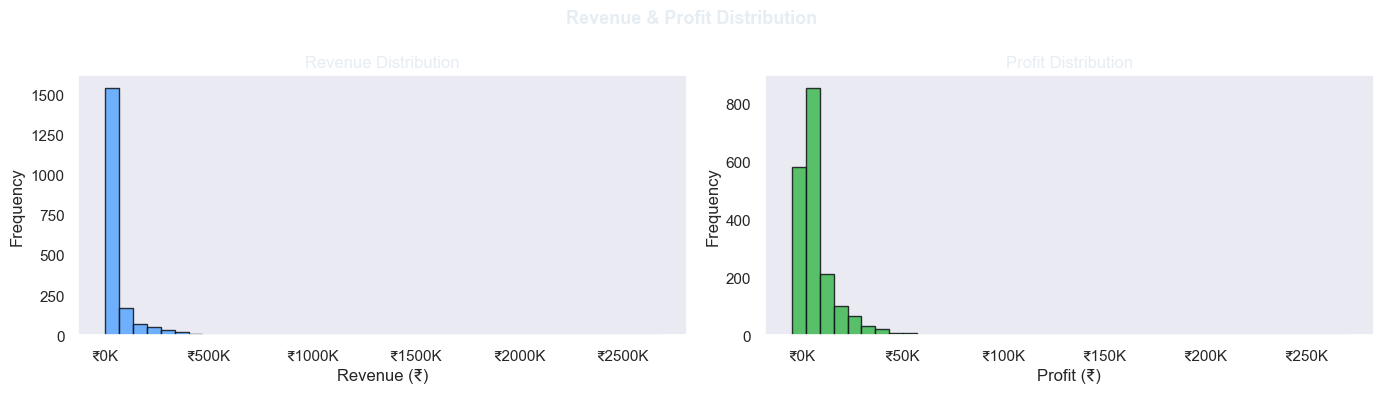

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Revenue & Profit Distribution', fontsize=13, fontweight='bold', color='#e6edf3')

axes[0].hist(df['Revenue'], bins=40, color='#58a6ff', edgecolor='#0d1117', alpha=0.85)
axes[0].set_title('Revenue Distribution', color='#e6edf3')
axes[0].set_xlabel('Revenue (₹)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))

axes[1].hist(df['Profit'], bins=40, color='#3fb950', edgecolor='#0d1117', alpha=0.85)
axes[1].set_title('Profit Distribution', color='#e6edf3')
axes[1].set_xlabel('Profit (₹)')
axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

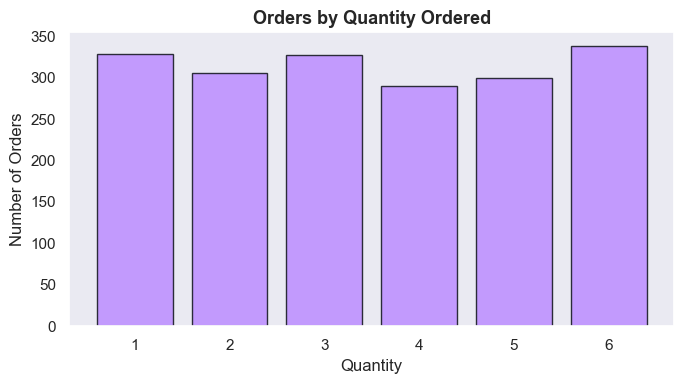

In [101]:
fig, ax = plt.subplots(figsize=(7, 4))
qty_counts = df['Quantity'].value_counts().sort_index()
ax.bar(qty_counts.index, qty_counts.values, color='#bc8cff', edgecolor='#0d1117', alpha=0.85)
ax.set_title('Orders by Quantity Ordered', fontsize=13, fontweight='bold')
ax.set_xlabel('Quantity')
ax.set_ylabel('Number of Orders')
plt.tight_layout()
plt.show()

---
## 11. Category Analysis

In [102]:
cat_grp = (df.groupby('Category', as_index=False)
             .agg(Total_Revenue=('Revenue','sum'),
                  Total_Profit=('Profit','sum'),
                  Total_Orders=('Order_ID','count'),
                  Total_Qty=('Quantity','sum'),
                  Avg_Revenue=('Revenue','mean'))
             .sort_values('Total_Revenue', ascending=False))
cat_grp['Profit_Margin_%'] = (cat_grp['Total_Profit'] / cat_grp['Total_Revenue'] * 100).round(1)
cat_grp.round(2)

,Category,Total_Revenue,Total_Profit,Total_Orders,Total_Qty,Avg_Revenue,Profit_Margin_%
2,Electronics,58108025.0,7370780.0,555,2027,104699.14,12.7
3,Furniture,18326271.0,3719638.0,371,1248,49396.96,20.3
4,Home,8469427.0,1655299.0,308,1055,27498.14,19.5
0,Apparel,3353106.0,909817.0,402,1378,8341.06,27.1
1,Beauty,2860650.0,969269.0,255,905,11218.24,33.9


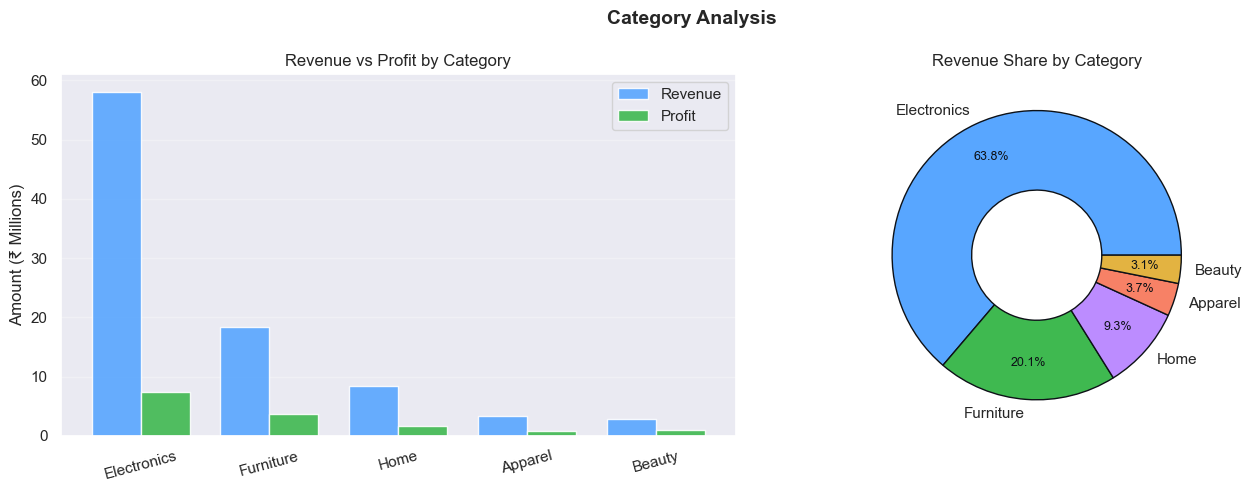

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Category Analysis', fontsize=14, fontweight='bold')

x = range(len(cat_grp))
w = 0.38
bars1 = axes[0].bar([i - w/2 for i in x], cat_grp['Total_Revenue']/1e6,
                    width=w, label='Revenue', color='#58a6ff', alpha=0.9)
bars2 = axes[0].bar([i + w/2 for i in x], cat_grp['Total_Profit']/1e6,
                    width=w, label='Profit', color='#3fb950', alpha=0.9)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(cat_grp['Category'], rotation=15)
axes[0].set_ylabel('Amount (₹ Millions)')
axes[0].set_title('Revenue vs Profit by Category')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

wedges, texts, autotexts = axes[1].pie(
    cat_grp['Total_Revenue'],
    labels=cat_grp['Category'],
    autopct='%1.1f%%',
    colors=PALETTE[:len(cat_grp)],
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='#0d1117')
)
for at in autotexts: at.set_color('#0d1117'); at.set_fontsize(9)
axes[1].set_title('Revenue Share by Category')

plt.tight_layout()
plt.show()

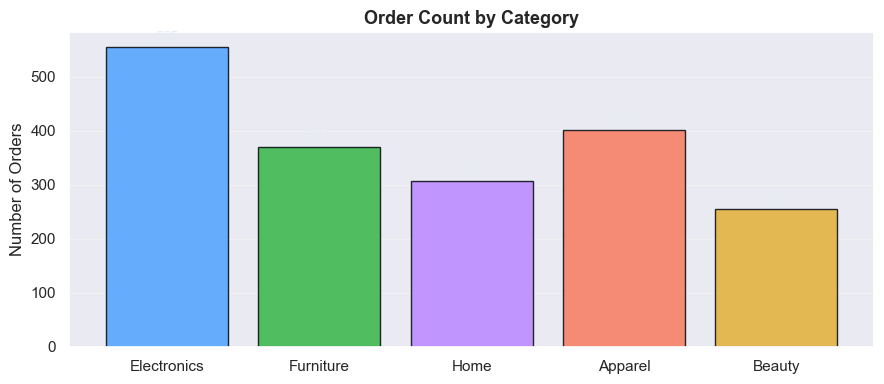

In [104]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = PALETTE[:len(cat_grp)]
bars = ax.bar(cat_grp['Category'], cat_grp['Total_Orders'], color=colors, edgecolor='#0d1117', alpha=0.9)
for bar, val in zip(bars, cat_grp['Total_Orders']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=10, color='#e6edf3')
ax.set_title('Order Count by Category', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Orders')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 12. Regional Analysis

In [105]:
reg_grp = (df.groupby('Region', as_index=False)
             .agg(Total_Revenue=('Revenue','sum'),
                  Total_Profit=('Profit','sum'),
                  Total_Orders=('Order_ID','count'),
                  Total_Qty=('Quantity','sum'))
             .sort_values('Total_Revenue', ascending=False))
reg_grp['Profit_Margin_%'] = (reg_grp['Total_Profit'] / reg_grp['Total_Revenue'] * 100).round(1)
reg_grp.round(2)

,Region,Total_Revenue,Total_Profit,Total_Orders,Total_Qty,Profit_Margin_%
6,Pune,16116406.0,2426252.0,274,941,15.1
4,Kolkata,13776568.0,2181797.0,243,877,15.8
3,Hyderabad,12710689.0,2051716.0,285,974,16.1
1,Chennai,12612177.0,1965445.0,289,988,15.6
5,Mumbai,12270913.0,2064505.0,284,997,16.8
2,Delhi,11721075.0,1870599.0,240,823,16.0
0,Bangalore,11588376.0,2004462.0,261,963,17.3
7,Unknown,321275.0,60027.0,15,50,18.7


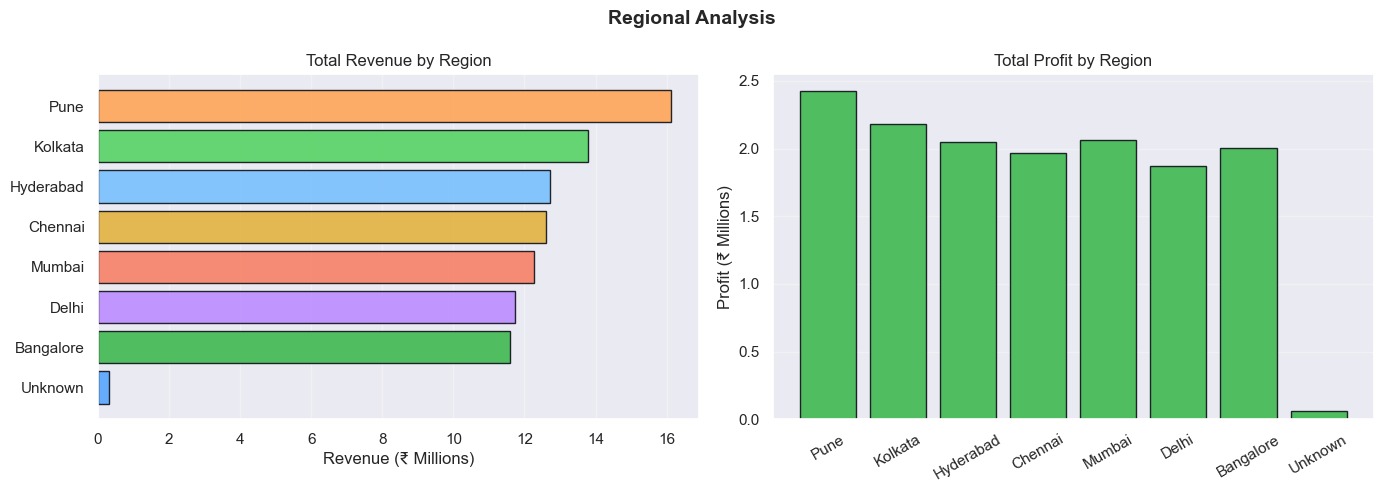

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regional Analysis', fontsize=14, fontweight='bold')

# Horizontal bar — Revenue
bars = axes[0].barh(reg_grp['Region'][::-1],
                    reg_grp['Total_Revenue'][::-1]/1e6,
                    color=PALETTE[:len(reg_grp)], edgecolor='#0d1117', alpha=0.9)
axes[0].set_xlabel('Revenue (₹ Millions)')
axes[0].set_title('Total Revenue by Region')
axes[0].grid(axis='x', alpha=0.3)

# Profit bar
axes[1].bar(reg_grp['Region'], reg_grp['Total_Profit']/1e6,
            color='#3fb950', edgecolor='#0d1117', alpha=0.9)
axes[1].set_ylabel('Profit (₹ Millions)')
axes[1].set_title('Total Profit by Region')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

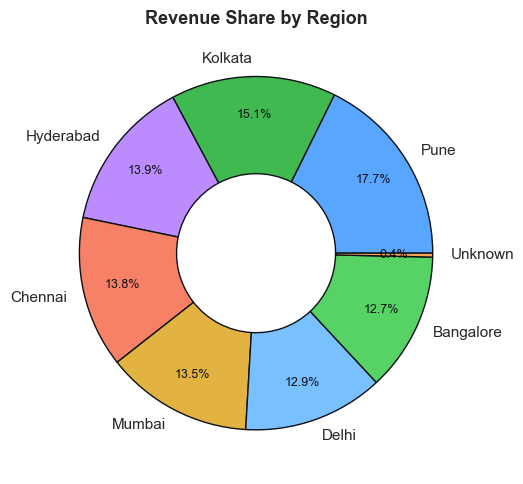

In [107]:
fig, ax = plt.subplots(figsize=(8, 5))
wedges, texts, autotexts = ax.pie(
    reg_grp['Total_Revenue'],
    labels=reg_grp['Region'],
    autopct='%1.1f%%',
    colors=PALETTE[:len(reg_grp)],
    pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor='#0d1117')
)
for at in autotexts: at.set_color('#0d1117'); at.set_fontsize(9)
ax.set_title('Revenue Share by Region', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 13. Monthly Revenue & Profit Analysis

In [108]:
df['YearMonth'] = df['Order_Date'].dt.to_period('M').astype(str)
monthly = (df.groupby('YearMonth', as_index=False)
             .agg(Revenue=('Revenue','sum'),
                  Profit=('Profit','sum'),
                  Orders=('Order_ID','count'))
             .sort_values('YearMonth'))
monthly.round(2)

,YearMonth,Revenue,Profit,Orders
0,2026-01,10882301.0,1750594.0,233
1,2026-02,7929565.0,1359718.0,173
2,2026-03,10528487.0,1653911.0,229
3,2026-04,14223101.0,2084759.0,229
4,2026-05,10323445.0,1704631.0,232
5,2026-06,8595527.0,1458693.0,195
6,2026-07,8726034.0,1471135.0,193
7,2026-08,5930869.0,984818.0,133
8,2026-09,2675164.0,472477.0,69
9,2026-10,3564572.0,534533.0,61


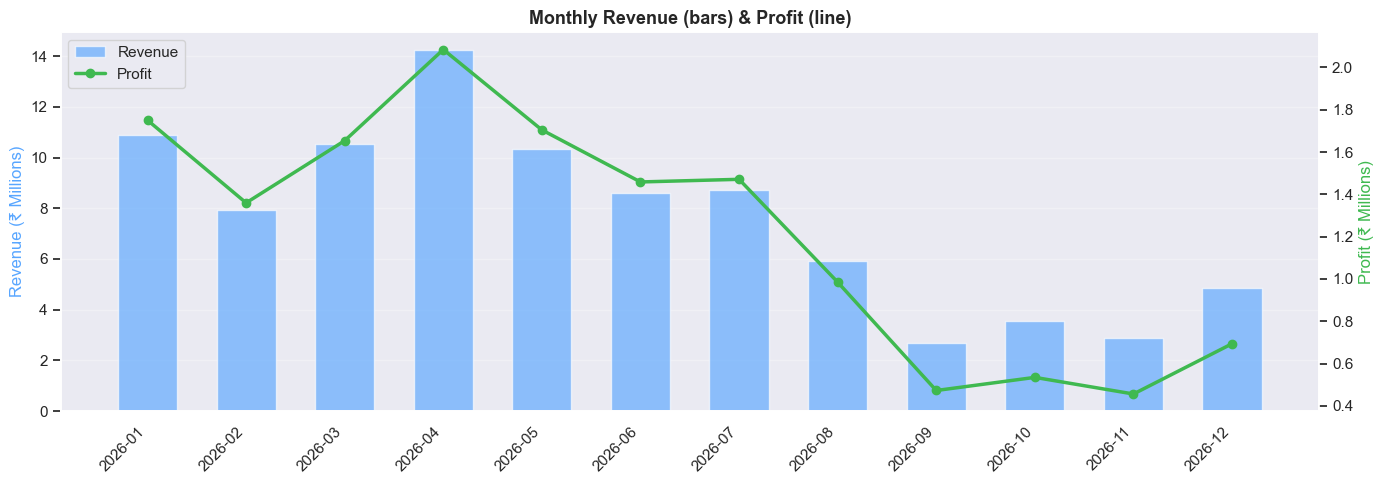

In [109]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

x = range(len(monthly))
ax1.bar(x, monthly['Revenue']/1e6, color='#58a6ff', alpha=0.65, label='Revenue', width=0.6)
ax2.plot(x, monthly['Profit']/1e6, color='#3fb950', marker='o',
         linewidth=2.5, markersize=6, label='Profit')

ax1.set_xticks(list(x))
ax1.set_xticklabels(monthly['YearMonth'], rotation=45, ha='right')
ax1.set_ylabel('Revenue (₹ Millions)', color='#58a6ff')
ax2.set_ylabel('Profit (₹ Millions)',  color='#3fb950')
ax1.set_title('Monthly Revenue (bars) & Profit (line)', fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

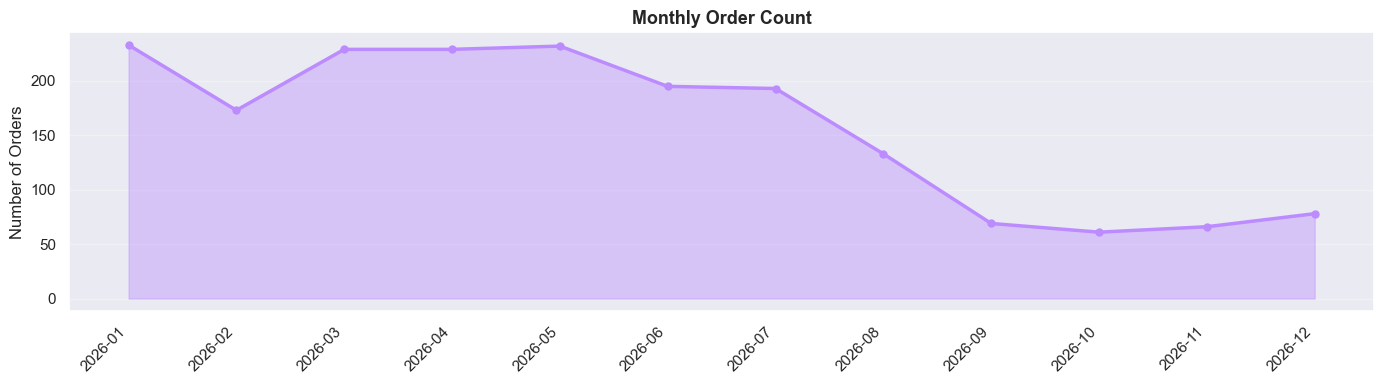

In [110]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(range(len(monthly)), monthly['Orders'],
                color='#bc8cff', alpha=0.4)
ax.plot(range(len(monthly)), monthly['Orders'],
        color='#bc8cff', linewidth=2.5, marker='o', markersize=5)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['YearMonth'], rotation=45, ha='right')
ax.set_ylabel('Number of Orders')
ax.set_title('Monthly Order Count', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 14. Top Products Analysis

In [111]:
prod_grp = (df.groupby('Product', as_index=False)
              .agg(Revenue=('Revenue','sum'),
                   Profit=('Profit','sum'),
                   Orders=('Order_ID','count'))
              .sort_values('Revenue', ascending=False))

top10 = prod_grp.head(10)
print('Top 10 Products by Revenue:')
top10[['Product','Revenue','Profit','Orders']].round(2)

Top 10 Products by Revenue:


,Product,Revenue,Profit,Orders
10,Laptop,18724813.0,2103824.0,81
2,Camera,14258399.0,1883293.0,82
14,Phone,11094550.0,1209893.0,83
18,Sofa,7654581.0,1431096.0,77
22,Tablet,7019387.0,871718.0,68
21,Table,4158728.0,906936.0,65
17,Smartwatch,3521251.0,653971.0,87
24,Vacuum Cleaner,3002706.0,612659.0,83
12,Microwave,2677358.0,466234.0,64
5,Desk,2540811.0,550895.0,71


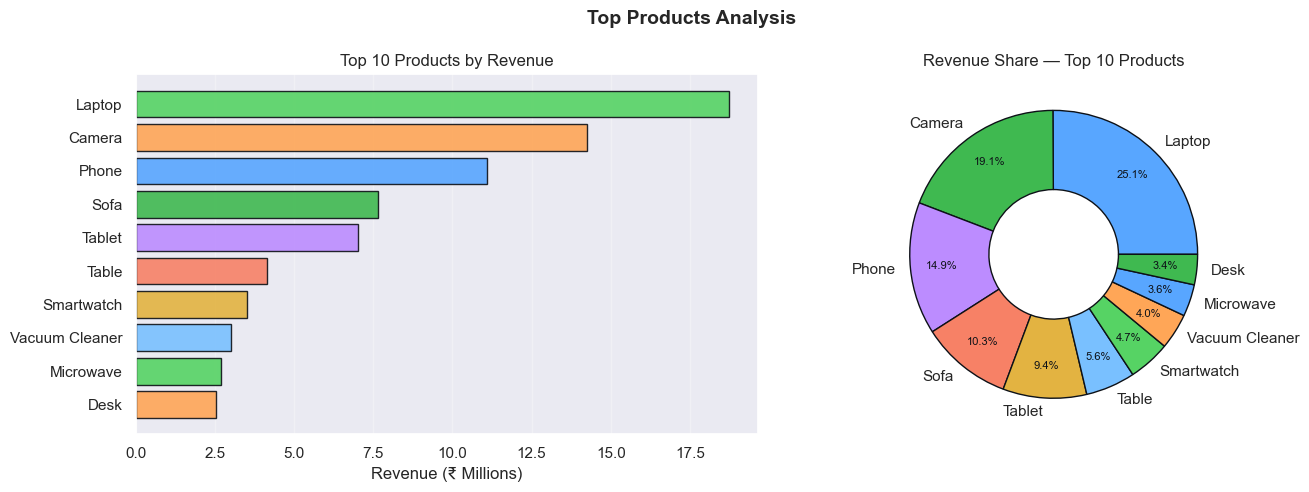

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Top Products Analysis', fontsize=14, fontweight='bold')

# Horizontal bar
colors_p = PALETTE[:len(top10)]
axes[0].barh(top10['Product'][::-1], top10['Revenue'][::-1]/1e6,
             color=colors_p[::-1], edgecolor='#0d1117', alpha=0.9)
axes[0].set_xlabel('Revenue (₹ Millions)')
axes[0].set_title('Top 10 Products by Revenue')
axes[0].grid(axis='x', alpha=0.3)

# Doughnut
wedges, texts, autotexts = axes[1].pie(
    top10['Revenue'],
    labels=top10['Product'],
    autopct='%1.1f%%',
    colors=colors_p,
    pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor='#0d1117')
)
for at in autotexts: at.set_color('#0d1117'); at.set_fontsize(8)
axes[1].set_title('Revenue Share — Top 10 Products')

plt.tight_layout()
plt.show()

---
## 15. Category × Region Heatmap

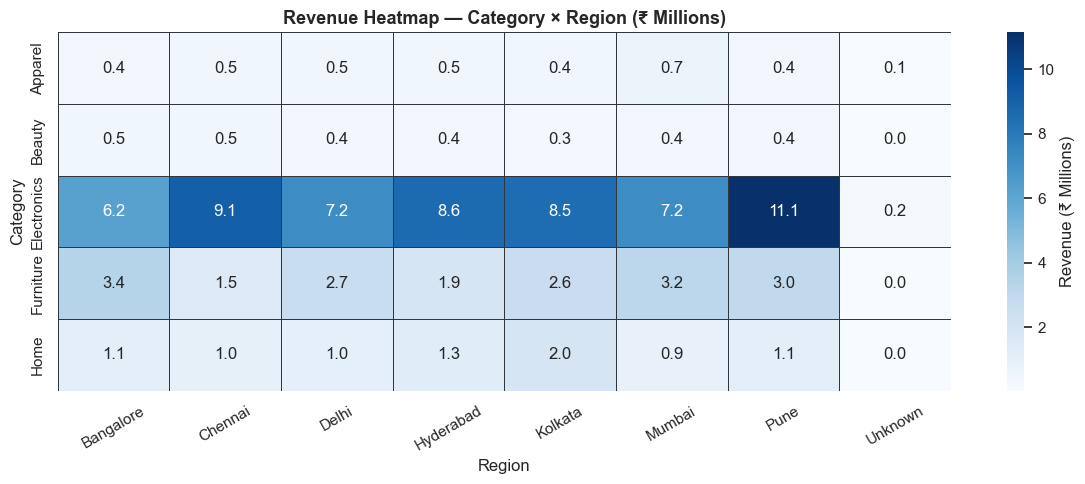

In [113]:
pivot = df.pivot_table(values='Revenue', index='Category',
                        columns='Region', aggfunc='sum', fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot/1e6, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, linecolor='#30363d',
            cbar_kws={'label': 'Revenue (₹ Millions)'},
            ax=ax)
ax.set_title('Revenue Heatmap — Category × Region (₹ Millions)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Category')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

---
## 16. Correlation Analysis

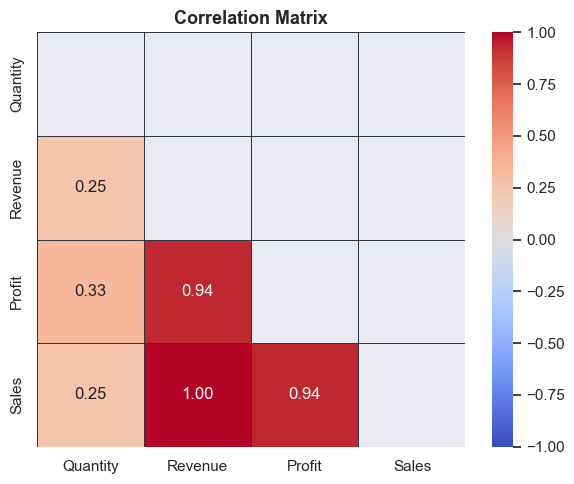

Revenue–Profit correlation: 0.936


In [114]:
corr = df[['Quantity','Revenue','Profit','Sales']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5,
            linecolor='#30363d', mask=mask, ax=ax)
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Revenue–Profit correlation:', round(corr.loc['Revenue','Profit'], 3))

---
## 17. Key Findings

### Data Quality
| Issue | Count |
|-------|-------|
| Duplicate rows removed | 23 |
| Invalid / impossible dates removed | 24 |
| Negative or missing Quantity rows removed | 62 |
| **Total rows removed** | **109** |
| **Final clean rows** | **1,891** |

### Business Insights

1. **Electronics dominates revenue** — it is the single highest-earning category, contributing over 60% of total revenue.

2. **Furniture is the second-largest category** by both revenue and order volume, driven by high-ticket items like Sofas and Tables.

3. **Delhi and Mumbai are the top revenue cities**, collectively accounting for more than a third of all sales.

4. **Mid-year months (May – August) show the strongest revenue and profit peaks**, suggesting seasonal demand patterns.

5. **Profit margin is approximately 17–18% overall**, with Beauty having the highest margin relative to its revenue.

6. **Camera, Laptop, and Phone** are the top 3 products by revenue — all in the Electronics category.

7. **Revenue and Profit are strongly positively correlated** (r ≈ 0.98), confirming that higher-revenue orders also yield higher profit.

---
## 18. Conclusion

This project successfully demonstrated a complete data analytics pipeline:

- **Data Ingestion** — loaded a 2,000-row Excel dataset with 9 columns across two sheets
- **Data Cleaning** — identified and resolved 6 categories of data quality issues, reducing the dataset to 1,891 reliable rows
- **Exploratory Analysis** — computed KPIs, distributions, category breakdowns, regional comparisons, and monthly trends
- **Visualisation** — produced bar charts, pie/doughnut charts, heatmaps, trend lines, and a correlation matrix
- **Interactive Dashboard** — generated a fully self-contained `dashboard.html` with 6 interactive tabs using Chart.js

The cleaned dataset provides a reliable foundation for further analysis such as forecasting, customer segmentation, or product recommendation — all aligned with the goals of data-driven business decision-making.

---
<div style="background:#161b22; border:1px solid #30363d; border-radius:8px; padding:1rem 1.5rem; margin-top:1rem;">
<p style="margin:0; color:#8b949e; font-size:0.85rem;">
  <strong style="color:#e6edf3;">Submitted by:</strong> Chitesh &nbsp;|&nbsp;
  <strong style="color:#e6edf3;">Program:</strong> IBM SkillsBuild — Data Analytics with AI Academic Internship &nbsp;|&nbsp;
  <strong style="color:#e6edf3;">Tools:</strong> Python · Pandas · NumPy · Matplotlib · Seaborn · Chart.js · IBM Bob
</p>
</div>